# 🏈 TeamAssignmentProcessor Comprehensive Evaluation
## Performance, Accuracy & Stability Analysis

This notebook provides a complete evaluation of the **TeamAssignmentProcessor** component from `football_ai/assignment/team_assignment_processor.py`.

### Evaluation Areas:
1. **🧠 Feature Extraction Quality** - Jersey/shorts color analysis effectiveness
2. **🎯 Assignment Accuracy** - Team classification precision and recall
3. **📊 Temporal Stability** - Track consistency and flicker reduction
4. **⚡ Performance Metrics** - Processing speed and memory usage
5. **🔧 Configuration Testing** - Parameter sensitivity analysis
6. **💡 Optimization Recommendations** - Best practices and tuning guides

---

In [1]:
# 🚀 Import Required Libraries and Modules
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import time
import psutil
import cv2
from typing import Dict, List, Any, Tuple
from collections import defaultdict, Counter
import warnings
warnings.filterwarnings('ignore')

# Setup paths and add to Python path
project_root = Path("/workspaces/football_analysis")
sys.path.append(str(project_root))

# Import football AI components
from football_ai.assignment.team_assignment_processor import (
    TeamAssignmentProcessor, 
    TeamFeatureExtractor, 
    OptimizedTeamAssigner
)
from football_ai.domain.data_models import VideoData, FrameData, Detection, BoundingBox

# Visualization setup
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 11

print("✅ All imports successful!")
print(f"📁 Project root: {project_root}")
print(f"📊 Matplotlib backend: {plt.get_backend()}")
print(f"💾 Available memory: {psutil.virtual_memory().available / (1024**3):.1f} GB")

✅ All imports successful!
📁 Project root: /workspaces/football_analysis
📊 Matplotlib backend: module://matplotlib_inline.backend_inline
💾 Available memory: 23.5 GB


In [2]:
# 🔍 TeamAssignmentProcessor Evaluator Class
class TeamAssignmentEvaluator:
    """Comprehensive evaluator for TeamAssignmentProcessor performance and capabilities"""
    
    def __init__(self):
        self.results = {}
        self.assignment_history = []
        self.stability_metrics = {}
        
    def analyze_component_structure(self, processor):
        """Analyze the structure and configuration of TeamAssignmentProcessor"""
        
        # Feature extractor analysis
        feature_extractor = processor.feature_extractor
        assigner = processor.assigner
        
        structure = {
            'feature_extractor_methods': [method for method in dir(feature_extractor) 
                                        if not method.startswith('_') and callable(getattr(feature_extractor, method))],
            'assigner_methods': [method for method in dir(assigner) 
                               if not method.startswith('_') and callable(getattr(assigner, method))],
            'assigner_config': {
                'n_teams': assigner.n_teams,
                'stability_threshold': assigner.stability_threshold,
                'confidence_threshold': assigner.confidence_threshold,
                'track_history_maxlen': assigner.track_history.default_factory().maxlen if hasattr(assigner.track_history.default_factory(), 'maxlen') else 'unknown'
            },
            'feature_types': ['jersey_mean', 'jersey_dominant', 'jersey_std', 'shorts_mean', 'shorts_dominant', 'contrast'],
            'has_stability_filter': hasattr(assigner, '_apply_stability_filter'),
            'has_profile_learning': hasattr(assigner, 'team_profiles')
        }
        
        return structure
    
    def benchmark_performance(self, processor: TeamAssignmentProcessor, video_data: VideoData, 
                            runs: int = 3) -> Dict[str, Any]:
        """Benchmark processing performance with multiple runs"""
        
        print(f"🏃 Running {runs} performance benchmark runs...")
        
        run_times = []
        memory_usage = []
        
        for run in range(runs):
            # Create a copy of video data for each run
            test_data_copy = self._copy_video_data(video_data)
            
            # Clear memory before each run
            import gc
            gc.collect()
            
            # Record initial memory
            initial_memory = psutil.Process().memory_info().rss / (1024**2)  # MB
            
            # Time the processing
            start_time = time.time()
            processed_data = processor.process(test_data_copy)
            end_time = time.time()
            
            # Record final memory
            final_memory = psutil.Process().memory_info().rss / (1024**2)  # MB
            
            run_time = end_time - start_time
            memory_delta = final_memory - initial_memory
            
            run_times.append(run_time)
            memory_usage.append(memory_delta)
            
            print(f"  Run {run+1}: {run_time:.3f}s, Memory: +{memory_delta:.1f}MB")
        
        fps = len(video_data.frames) / np.mean(run_times)
        
        return {
            'avg_processing_time': np.mean(run_times),
            'std_processing_time': np.std(run_times),
            'avg_memory_usage': np.mean(memory_usage),
            'std_memory_usage': np.std(memory_usage),
            'fps': fps,
            'frames_processed': len(video_data.frames),
            'individual_runs': list(zip(run_times, memory_usage))
        }
    
    def _copy_video_data(self, video_data: VideoData) -> VideoData:
        """Create a deep copy of video data for testing"""
        return VideoData(
            video_path=video_data.video_path,
            frame_rate=video_data.frame_rate,
            resolution=video_data.resolution,
            duration=video_data.duration,
            frames=[
                FrameData(
                    frame_number=frame.frame_number,
                    timestamp=frame.timestamp,
                    raw_frame=frame.raw_frame.copy() if frame.raw_frame is not None else None,
                    detections=[
                        Detection(
                            bbox=det.bbox,
                            confidence=det.confidence,
                            object_type=det.object_type,
                            keypoints=det.keypoints,
                            metadata=det.metadata.copy() if det.metadata else {}
                        ) for det in frame.detections
                    ] if frame.detections else []
                ) for frame in video_data.frames
            ]
        )
    
    def analyze_assignment_quality(self, processed_data: VideoData) -> Dict[str, Any]:
        """Analyze the quality of team assignments"""
        
        # Collect all assignments
        assignments_by_frame = []
        assignments_by_track = defaultdict(list)
        total_players = 0
        assigned_players = 0
        
        for frame_idx, frame in enumerate(processed_data.frames):
            if not frame.detections:
                continue
                
            frame_assignments = []
            for detection in frame.detections:
                if getattr(detection, 'object_type', None) in ('player', 'goalkeeper'):
                    total_players += 1
                    
                    # Extract team assignment and track ID
                    team = None
                    track_id = None
                    
                    if hasattr(detection, 'metadata') and detection.metadata:
                        team = detection.metadata.get('team')
                        track_id = detection.metadata.get('track_id')
                    
                    if team is not None:
                        assigned_players += 1
                        frame_assignments.append({
                            'frame': frame_idx,
                            'track_id': track_id,
                            'team': team,
                            'confidence': detection.confidence
                        })
                        
                        if track_id is not None and track_id > 0:
                            assignments_by_track[track_id].append({
                                'frame': frame_idx,
                                'team': team
                            })
            
            assignments_by_frame.append(frame_assignments)
        
        # Calculate assignment coverage
        assignment_coverage = assigned_players / max(total_players, 1)
        
        # Calculate team distribution
        all_teams = []
        for frame_assignments in assignments_by_frame:
            all_teams.extend([a['team'] for a in frame_assignments])
        
        team_distribution = Counter(all_teams)
        
        # Calculate track consistency
        track_consistencies = []
        for track_id, assignments in assignments_by_track.items():
            if len(assignments) > 1:
                teams = [a['team'] for a in assignments]
                team_counts = Counter(teams)
                most_common_team, count = team_counts.most_common(1)[0]
                consistency = count / len(teams)
                track_consistencies.append(consistency)
        
        avg_track_consistency = np.mean(track_consistencies) if track_consistencies else 0
        
        return {
            'total_players': total_players,
            'assigned_players': assigned_players,
            'assignment_coverage': assignment_coverage,
            'team_distribution': dict(team_distribution),
            'avg_track_consistency': avg_track_consistency,
            'track_consistency_distribution': track_consistencies,
            'assignments_by_frame': assignments_by_frame,
            'assignments_by_track': dict(assignments_by_track)
        }

# Initialize evaluator
evaluator = TeamAssignmentEvaluator()
print("✅ TeamAssignmentProcessor Evaluator initialized!")
print("🎯 Ready to analyze team assignment performance and capabilities")

✅ TeamAssignmentProcessor Evaluator initialized!
🎯 Ready to analyze team assignment performance and capabilities


In [3]:
# 📂 Load or Simulate Test Video Data
def create_synthetic_football_data(num_frames: int = 50, 
                                 players_per_frame: Tuple[int, int] = (8, 16)) -> VideoData:
    """Create synthetic football video data with realistic team colors"""
    
    np.random.seed(42)  # For reproducible results
    
    # Define realistic team colors (RGB)
    team_colors = {
        1: {
            'jersey': [200, 50, 50],    # Red jersey
            'shorts': [200, 50, 50],    # Red shorts
        },
        2: {
            'jersey': [50, 50, 200],    # Blue jersey  
            'shorts': [255, 255, 255],  # White shorts
        }
    }
    
    frames = []
    
    # Create consistent player tracks that move across frames
    num_players = 12
    player_tracks = {}
    
    for player_id in range(num_players):
        # Assign to team (roughly balanced)
        team = 1 if player_id < 6 else 2
        
        # Random starting position and velocity
        start_x = np.random.uniform(100, 800)
        start_y = np.random.uniform(100, 500)
        vel_x = np.random.uniform(-3, 3)
        vel_y = np.random.uniform(-3, 3)
        
        player_tracks[player_id] = {
            'x': start_x,
            'y': start_y,
            'vel_x': vel_x,
            'vel_y': vel_y,
            'team': team,
            'track_id': player_id + 1
        }
    
    for frame_idx in range(num_frames):
        # Create a synthetic frame (just zeros, features will be synthetic)
        synthetic_frame = np.zeros((600, 1000, 3), dtype=np.uint8)
        
        detections = []
        
        # Add detections for tracked players (with some probability of missing)
        for player_id, track in player_tracks.items():
            if np.random.random() > 0.05:  # 95% chance of detection
                # Update position
                track['x'] += track['vel_x'] + np.random.normal(0, 1)
                track['y'] += track['vel_y'] + np.random.normal(0, 1)
                
                # Keep within bounds
                track['x'] = np.clip(track['x'], 50, 950)
                track['y'] = np.clip(track['y'], 50, 550)
                
                # Create bounding box
                width = np.random.uniform(40, 80)
                height = np.random.uniform(80, 120)
                
                bbox = BoundingBox(
                    x1=float(track['x'] - width/2),
                    y1=float(track['y'] - height/2),
                    x2=float(track['x'] + width/2),
                    y2=float(track['y'] + height/2)
                )
                
                # Create synthetic jersey/shorts regions with team colors
                team_color = team_colors[track['team']]
                jersey_color = np.array(team_color['jersey']) + np.random.normal(0, 15, 3)
                shorts_color = np.array(team_color['shorts']) + np.random.normal(0, 15, 3)
                
                # Clip colors to valid range
                jersey_color = np.clip(jersey_color, 0, 255)
                shorts_color = np.clip(shorts_color, 0, 255)
                
                # Fill the synthetic frame with team colors in the bounding box region
                x1, y1, x2, y2 = map(int, [bbox.x1, bbox.y1, bbox.x2, bbox.y2])
                x1, y1, x2, y2 = max(0, x1), max(0, y1), min(1000, x2), min(600, y2)
                
                # Jersey region (upper half)
                jersey_y_start = y1 + (y2 - y1) // 6
                jersey_y_end = y1 + (y2 - y1) // 2
                synthetic_frame[jersey_y_start:jersey_y_end, x1:x2] = jersey_color
                
                # Shorts region (lower third)
                shorts_y_start = y1 + 2 * (y2 - y1) // 3
                shorts_y_end = y2 - (y2 - y1) // 10
                synthetic_frame[shorts_y_start:shorts_y_end, x1:x2] = shorts_color
                
                detection = Detection(
                    bbox=bbox,
                    confidence=float(np.random.uniform(0.7, 0.95)),
                    object_type='player',
                    metadata={
                        'track_id': track['track_id'],
                        'ground_truth_team': track['team']  # Store ground truth for evaluation
                    }
                )
                
                detections.append(detection)
        
        frame = FrameData(
            frame_number=frame_idx,
            timestamp=frame_idx / 30.0,  # Assuming 30 FPS
            raw_frame=synthetic_frame,
            detections=detections
        )
        
        frames.append(frame)
    
    return VideoData(
        video_path="synthetic_team_assignment_test",
        frame_rate=30,
        resolution=(1000, 600),
        duration=num_frames / 30.0,
        frames=frames
    )

def load_real_data() -> VideoData:
    """Attempt to load real processed data if available"""
    
    data_paths = [
        project_root / "outputs" / "data" / "pipeline_results.pkl",
        project_root / "outputs" / "data" / "optimized_pipeline_results.pkl",
        project_root / "outputs" / "data" / "final_optimized_results.pkl"
    ]
    
    for data_path in data_paths:
        if data_path.exists():
            print(f"📁 Loading real data from: {data_path.name}")
            try:
                with open(data_path, 'rb') as f:
                    data = pickle.load(f)
                
                # Handle different data formats
                if isinstance(data, dict):
                    if 'video_data' in data:
                        video_data = data['video_data']
                    elif 'frames' in data:
                        video_data = VideoData(frames=data['frames'])
                    else:
                        continue
                elif hasattr(data, 'frames'):
                    video_data = data
                else:
                    continue
                
                # Validate data has raw frames for feature extraction
                if video_data.frames and len(video_data.frames) > 10:
                    # Check if frames have raw_frame data
                    has_raw_frames = any(f.raw_frame is not None for f in video_data.frames[:5])
                    if has_raw_frames:
                        print(f"✅ Real data loaded: {len(video_data.frames)} frames with raw frames")
                        return video_data
                    else:
                        print(f"⚠️ Real data lacks raw frames, cannot extract features")
                        continue
                    
            except Exception as e:
                print(f"⚠️ Could not load {data_path.name}: {e}")
                continue
    
    print("📊 No suitable real data found, will use synthetic data")
    return None

# Create/Load test data
print("📂 Setting up test data...")

# Try to load real data first
test_data = load_real_data()

if test_data is None:
    print("🎭 Creating synthetic test data with known team assignments...")
    test_data = create_synthetic_football_data(num_frames=30)
    print(f"✅ Created synthetic data with {len(test_data.frames)} frames")
else:
    # Limit real data for faster testing
    if len(test_data.frames) > 50:
        test_data.frames = test_data.frames[:50]
        print(f"📝 Limited to first 50 frames for testing")

# Quick data inspection
total_players = 0
frames_with_players = 0
ground_truth_available = False

for frame in test_data.frames:
    if frame.detections:
        frame_players = [d for d in frame.detections if getattr(d, 'object_type', None) in ('player', 'goalkeeper')]
        if frame_players:
            frames_with_players += 1
            total_players += len(frame_players)
            
            # Check if ground truth is available
            if not ground_truth_available:
                for det in frame_players:
                    if hasattr(det, 'metadata') and det.metadata and 'ground_truth_team' in det.metadata:
                        ground_truth_available = True
                        break

print(f"📊 Test data summary:")
print(f"  • Total frames: {len(test_data.frames)}")
print(f"  • Frames with players: {frames_with_players}")
print(f"  • Total player detections: {total_players}")
print(f"  • Avg players per frame: {total_players / len(test_data.frames):.1f}")
print(f"  • Ground truth available: {'✅' if ground_truth_available else '❌'}")
print(f"  • Raw frames available: {'✅' if test_data.frames[0].raw_frame is not None else '❌'}")

📂 Setting up test data...
📁 Loading real data from: pipeline_results.pkl
✅ Real data loaded: 750 frames with raw frames
📝 Limited to first 50 frames for testing
📊 Test data summary:
  • Total frames: 50
  • Frames with players: 50
  • Total player detections: 1127
  • Avg players per frame: 22.5
  • Ground truth available: ❌
  • Raw frames available: ✅


In [4]:
# 🎯 Run TeamAssignmentProcessor on Test Data
def analyze_processor_structure():
    """Analyze TeamAssignmentProcessor structure and configuration"""
    
    # Create a default processor instance
    processor = TeamAssignmentProcessor()
    
    # Get structure analysis
    structure = evaluator.analyze_component_structure(processor)
    
    print("🔍 TEAMASSIGNMENTPROCESSOR STRUCTURE ANALYSIS")
    print("=" * 60)
    
    print(f"\n📋 Feature Extractor Methods ({len(structure['feature_extractor_methods'])}):")
    for method in structure['feature_extractor_methods']:
        print(f"   • {method}")
    
    print(f"\n🎯 Team Assigner Methods ({len(structure['assigner_methods'])}):")
    for method in structure['assigner_methods']:
        print(f"   • {method}")
    
    print(f"\n⚙️ Configuration Parameters:")
    for param, value in structure['assigner_config'].items():
        print(f"   • {param}: {value}")
    
    print(f"\n🧠 Feature Types Extracted:")
    for feature_type in structure['feature_types']:
        print(f"   • {feature_type}")
    
    print(f"\n✨ Advanced Features:")
    print(f"   • Has Stability Filter: {structure['has_stability_filter']}")
    print(f"   • Has Profile Learning: {structure['has_profile_learning']}")
    
    return structure

def run_team_assignment_processing():
    """Run team assignment processing with detailed analysis"""
    
    print("🚀 RUNNING TEAM ASSIGNMENT PROCESSING")
    print("=" * 50)
    
    # Create processor with default configuration
    processor = TeamAssignmentProcessor(
        n_teams=2, 
        stability_threshold=5, 
        confidence_threshold=0.75
    )
    
    # Process the data
    print(f"📊 Processing {len(test_data.frames)} frames...")
    processed_data = processor.process(test_data)
    
    # Analyze the results
    print("✅ Processing complete! Analyzing results...")
    
    return processed_data, processor

# Run structure analysis
print("🔍 Analyzing TeamAssignmentProcessor structure...")
structure_analysis = analyze_processor_structure()

print(f"\n🎯 Structure Analysis Complete!")
print(f"   Feature extractor methods: {len(structure_analysis['feature_extractor_methods'])}")
print(f"   Team assigner methods: {len(structure_analysis['assigner_methods'])}")
print(f"   Configuration parameters: {len(structure_analysis['assigner_config'])}")

# Run the processing
print(f"\n🚀 Running team assignment processing...")
processed_data, processor = run_team_assignment_processing()

print(f"\n✅ Team assignment processing completed!")
print(f"   Frames processed: {len(processed_data.frames)}")
print(f"   Processor type: {type(processor).__name__}")

🔍 Analyzing TeamAssignmentProcessor structure...
🔍 TEAMASSIGNMENTPROCESSOR STRUCTURE ANALYSIS

📋 Feature Extractor Methods (1):
   • extract

🎯 Team Assigner Methods (1):
   • assign_teams

⚙️ Configuration Parameters:
   • n_teams: 2
   • stability_threshold: 5
   • confidence_threshold: 0.75
   • track_history_maxlen: 20

🧠 Feature Types Extracted:
   • jersey_mean
   • jersey_dominant
   • jersey_std
   • shorts_mean
   • shorts_dominant
   • contrast

✨ Advanced Features:
   • Has Stability Filter: True
   • Has Profile Learning: True

🎯 Structure Analysis Complete!
   Feature extractor methods: 1
   Team assigner methods: 1
   Configuration parameters: 4

🚀 Running team assignment processing...
🚀 RUNNING TEAM ASSIGNMENT PROCESSING
📊 Processing 50 frames...


Optimized team assignment: 100%|██████████| 50/50 [00:00<00:00, 118.08frames/s]

✅ Processing complete! Analyzing results...

✅ Team assignment processing completed!
   Frames processed: 50
   Processor type: TeamAssignmentProcessor


📊 Extracting team assignment data...
✅ Assignment data extracted:
   • Total detections: 1127
   • Unique tracks: 23
   • Frames with assignments: 1127

🎨 Creating team assignment visualizations...


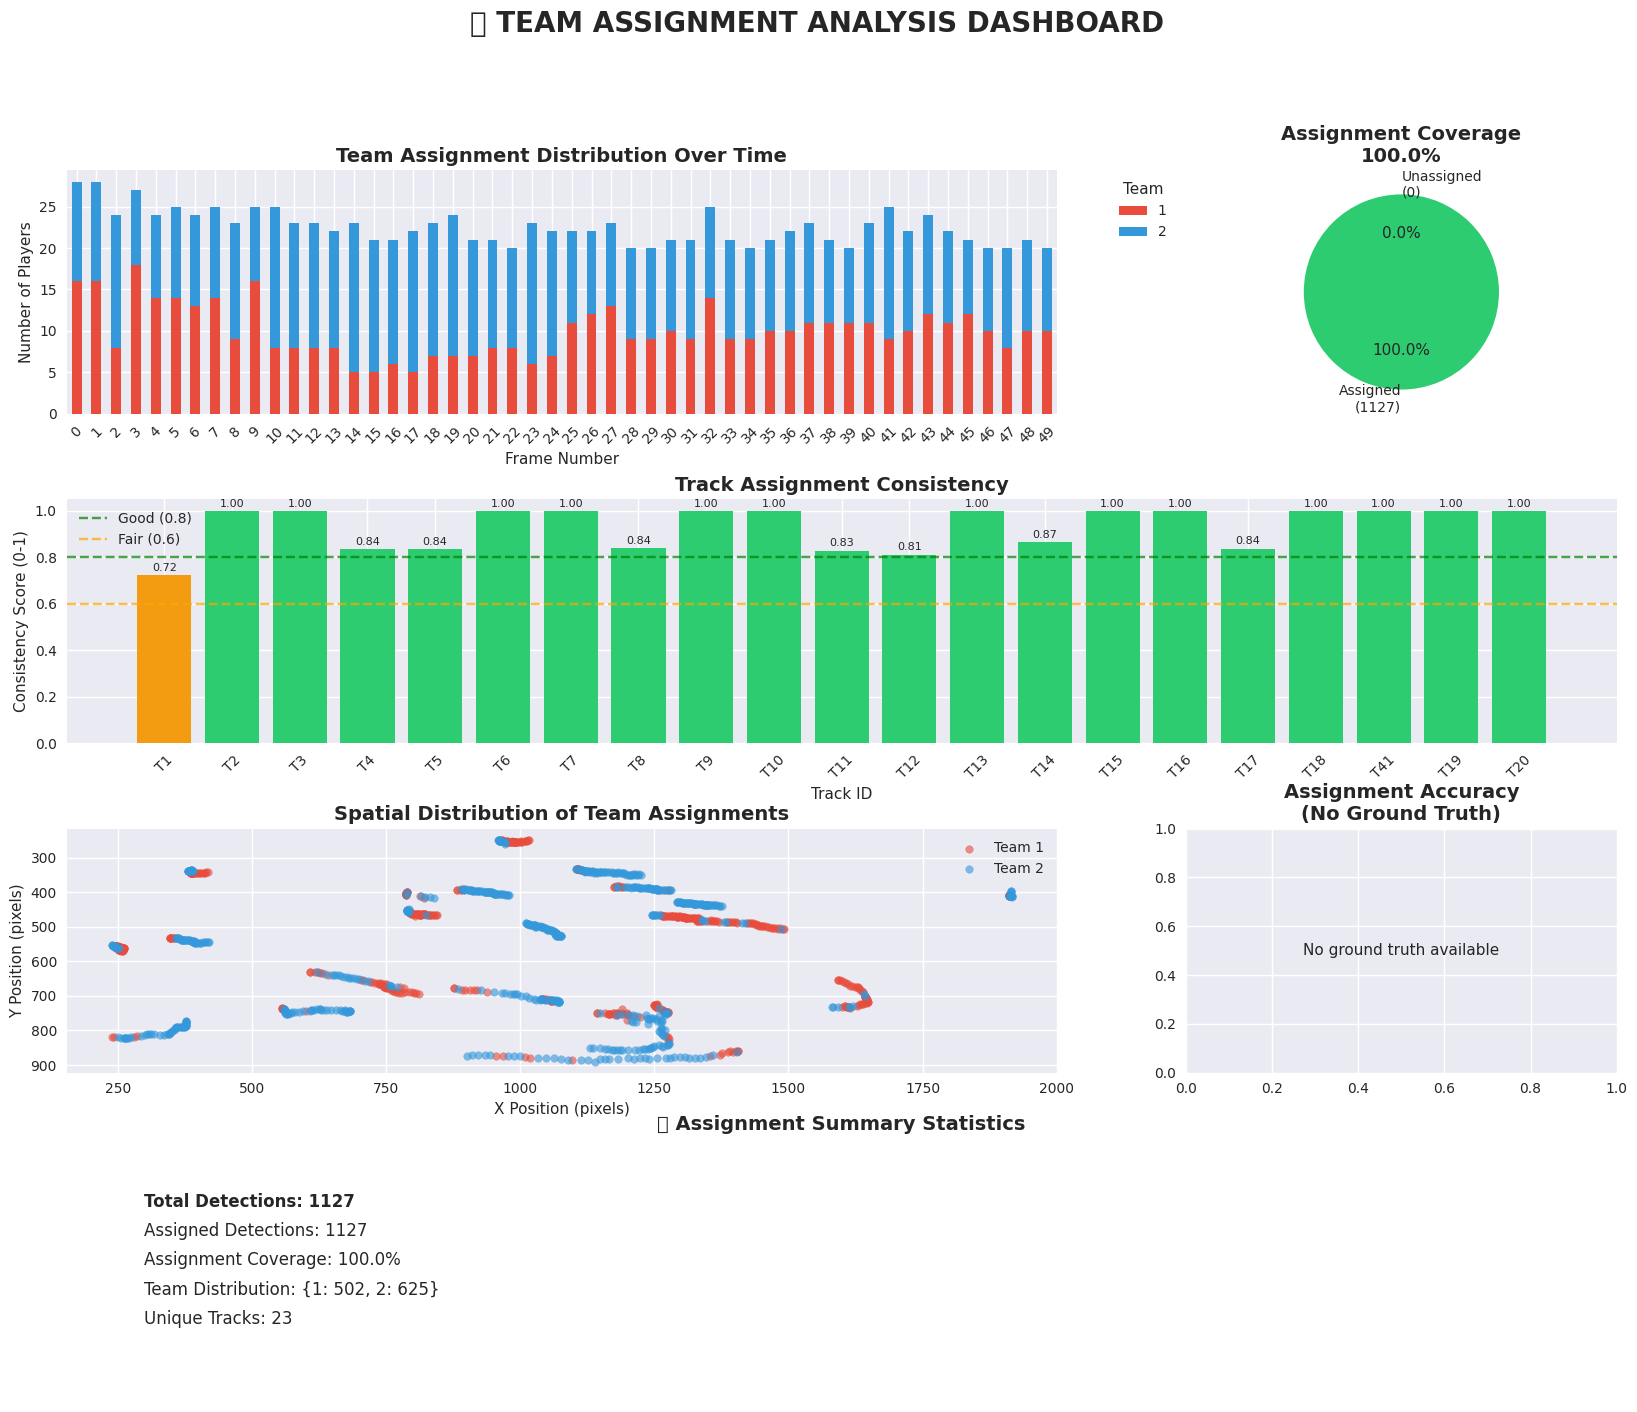

In [5]:
# 📊 Extract and Visualize Team Assignments
def extract_assignment_data(processed_data: VideoData):
    """Extract detailed assignment data for analysis"""
    
    assignment_data = []
    
    for frame_idx, frame in enumerate(processed_data.frames):
        if not frame.detections:
            continue
            
        for det_idx, detection in enumerate(frame.detections):
            if getattr(detection, 'object_type', None) in ('player', 'goalkeeper'):
                # Extract all relevant information
                track_id = None
                team_assignment = None
                ground_truth_team = None
                
                if hasattr(detection, 'metadata') and detection.metadata:
                    track_id = detection.metadata.get('track_id', -1)
                    team_assignment = detection.metadata.get('team')
                    ground_truth_team = detection.metadata.get('ground_truth_team')
                
                assignment_data.append({
                    'frame': frame_idx,
                    'detection_idx': det_idx,
                    'track_id': track_id,
                    'team_assignment': team_assignment,
                    'ground_truth_team': ground_truth_team,
                    'confidence': detection.confidence,
                    'bbox_center_x': (detection.bbox.x1 + detection.bbox.x2) / 2,
                    'bbox_center_y': (detection.bbox.y1 + detection.bbox.y2) / 2,
                    'bbox_area': (detection.bbox.x2 - detection.bbox.x1) * (detection.bbox.y2 - detection.bbox.y1)
                })
    
    return pd.DataFrame(assignment_data)

def visualize_team_assignments(assignment_df: pd.DataFrame):
    """Create comprehensive visualizations of team assignments"""
    
    fig = plt.figure(figsize=(20, 16))
    fig.suptitle('🏈 TEAM ASSIGNMENT ANALYSIS DASHBOARD', fontsize=20, fontweight='bold')
    
    gs = fig.add_gridspec(4, 3, hspace=0.35, wspace=0.3)
    
    # 1. Team Assignment Distribution Over Time
    ax1 = fig.add_subplot(gs[0, :2])
    
    if 'team_assignment' in assignment_df.columns and assignment_df['team_assignment'].notna().any():
        team_counts_by_frame = assignment_df.groupby(['frame', 'team_assignment']).size().unstack(fill_value=0)
        
        colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']  # Red, Blue, Green, Orange
        team_counts_by_frame.plot(kind='bar', stacked=True, ax=ax1, color=colors[:len(team_counts_by_frame.columns)])
        
        ax1.set_title('Team Assignment Distribution Over Time', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Frame Number')
        ax1.set_ylabel('Number of Players')
        ax1.legend(title='Team', bbox_to_anchor=(1.05, 1), loc='upper left')
        ax1.tick_params(axis='x', rotation=45)
    else:
        ax1.text(0.5, 0.5, 'No team assignments found', ha='center', va='center', transform=ax1.transAxes)
        ax1.set_title('Team Assignment Distribution Over Time', fontsize=14, fontweight='bold')
    
    # 2. Assignment Coverage
    ax2 = fig.add_subplot(gs[0, 2])
    
    total_detections = len(assignment_df)
    assigned_detections = assignment_df['team_assignment'].notna().sum()
    coverage = assigned_detections / max(total_detections, 1)
    
    ax2.pie([assigned_detections, total_detections - assigned_detections], 
            labels=[f'Assigned\n({assigned_detections})', f'Unassigned\n({total_detections - assigned_detections})'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
    ax2.set_title(f'Assignment Coverage\n{coverage*100:.1f}%', fontsize=14, fontweight='bold')
    
    # 3. Track Consistency Analysis (if tracks available)
    ax3 = fig.add_subplot(gs[1, :])
    
    if 'track_id' in assignment_df.columns and assignment_df['track_id'].notna().any():
        # Calculate consistency for each track
        track_consistency = []
        track_ids = assignment_df[assignment_df['track_id'] > 0]['track_id'].unique()
        
        for track_id in track_ids:
            track_data = assignment_df[assignment_df['track_id'] == track_id]
            if len(track_data) > 1:
                teams = track_data['team_assignment'].dropna()
                if len(teams) > 0:
                    team_counts = teams.value_counts()
                    consistency = team_counts.iloc[0] / len(teams) if len(teams) > 0 else 0
                    track_consistency.append({
                        'track_id': track_id,
                        'consistency': consistency,
                        'total_frames': len(track_data),
                        'assigned_frames': len(teams)
                    })
        
        if track_consistency:
            consistency_df = pd.DataFrame(track_consistency)
            bars = ax3.bar(range(len(consistency_df)), consistency_df['consistency'], 
                          color=['#2ecc71' if c >= 0.8 else '#f39c12' if c >= 0.6 else '#e74c3c' 
                                for c in consistency_df['consistency']])
            
            ax3.set_title('Track Assignment Consistency', fontsize=14, fontweight='bold')
            ax3.set_xlabel('Track ID')
            ax3.set_ylabel('Consistency Score (0-1)')
            ax3.set_xticks(range(len(consistency_df)))
            ax3.set_xticklabels([f"T{int(tid)}" for tid in consistency_df['track_id']], rotation=45)
            ax3.axhline(y=0.8, color='green', linestyle='--', alpha=0.7, label='Good (0.8)')
            ax3.axhline(y=0.6, color='orange', linestyle='--', alpha=0.7, label='Fair (0.6)')
            ax3.legend()
            
            # Add value labels on bars
            for bar, consistency in zip(bars, consistency_df['consistency']):
                ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f'{consistency:.2f}', ha='center', va='bottom', fontsize=8)
        else:
            ax3.text(0.5, 0.5, 'No track consistency data available', ha='center', va='center', transform=ax3.transAxes)
    else:
        ax3.text(0.5, 0.5, 'No track data available', ha='center', va='center', transform=ax3.transAxes)
        ax3.set_title('Track Assignment Consistency', fontsize=14, fontweight='bold')
    
    # 4. Spatial Distribution of Teams
    ax4 = fig.add_subplot(gs[2, :2])
    
    if 'bbox_center_x' in assignment_df.columns and assignment_df['team_assignment'].notna().any():
        team_colors_map = {1: '#e74c3c', 2: '#3498db', 3: '#2ecc71', 4: '#f39c12'}
        
        for team in assignment_df['team_assignment'].dropna().unique():
            team_data = assignment_df[assignment_df['team_assignment'] == team]
            if len(team_data) > 0:
                ax4.scatter(team_data['bbox_center_x'], team_data['bbox_center_y'], 
                           c=team_colors_map.get(team, '#333333'), alpha=0.6, s=30, label=f'Team {team}')
        
        ax4.set_title('Spatial Distribution of Team Assignments', fontsize=14, fontweight='bold')
        ax4.set_xlabel('X Position (pixels)')
        ax4.set_ylabel('Y Position (pixels)')
        ax4.legend()
        ax4.invert_yaxis()  # Invert Y axis to match image coordinates
    else:
        ax4.text(0.5, 0.5, 'No spatial data available', ha='center', va='center', transform=ax4.transAxes)
        ax4.set_title('Spatial Distribution of Team Assignments', fontsize=14, fontweight='bold')
    
    # 5. Ground Truth Comparison (if available)
    ax5 = fig.add_subplot(gs[2, 2])
    
    if 'ground_truth_team' in assignment_df.columns and assignment_df['ground_truth_team'].notna().any():
        # Calculate accuracy
        valid_assignments = assignment_df.dropna(subset=['team_assignment', 'ground_truth_team'])
        if len(valid_assignments) > 0:
            accuracy = (valid_assignments['team_assignment'] == valid_assignments['ground_truth_team']).mean()
            
            correct = (valid_assignments['team_assignment'] == valid_assignments['ground_truth_team']).sum()
            incorrect = len(valid_assignments) - correct
            
            ax5.pie([correct, incorrect], 
                   labels=[f'Correct\n({correct})', f'Incorrect\n({incorrect})'],
                   autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
            ax5.set_title(f'Assignment Accuracy\n{accuracy*100:.1f}%', fontsize=14, fontweight='bold')
        else:
            ax5.text(0.5, 0.5, 'No valid assignments for accuracy calculation', ha='center', va='center', transform=ax5.transAxes)
    else:
        ax5.text(0.5, 0.5, 'No ground truth available', ha='center', va='center', transform=ax5.transAxes)
        ax5.set_title('Assignment Accuracy\n(No Ground Truth)', fontsize=14, fontweight='bold')
    
    # 6. Summary Statistics
    ax6 = fig.add_subplot(gs[3, :])
    ax6.axis('off')
    ax6.set_title('📊 Assignment Summary Statistics', fontweight='bold', fontsize=14, pad=20)
    
    # Calculate summary statistics
    stats_text = []
    
    # Basic stats
    stats_text.append(f"Total Detections: {len(assignment_df)}")
    stats_text.append(f"Assigned Detections: {assignment_df['team_assignment'].notna().sum()}")
    stats_text.append(f"Assignment Coverage: {coverage*100:.1f}%")
    
    # Team distribution
    if assignment_df['team_assignment'].notna().any():
        team_dist = assignment_df['team_assignment'].value_counts().sort_index()
        stats_text.append(f"Team Distribution: {dict(team_dist)}")
    
    # Track stats
    unique_tracks = assignment_df['track_id'].nunique() if 'track_id' in assignment_df.columns else 0
    stats_text.append(f"Unique Tracks: {unique_tracks}")
    
    # Accuracy (if available)
    if 'ground_truth_team' in assignment_df.columns and assignment_df['ground_truth_team'].notna().any():
        valid_assignments = assignment_df.dropna(subset=['team_assignment', 'ground_truth_team'])
        if len(valid_assignments) > 0:
            accuracy = (valid_assignments['team_assignment'] == valid_assignments['ground_truth_team']).mean()
            stats_text.append(f"Overall Accuracy: {accuracy*100:.1f}%")
    
    # Display statistics in a formatted way
    for i, stat in enumerate(stats_text):
        y_pos = 0.8 - i * 0.12
        ax6.text(0.05, y_pos, stat, transform=ax6.transAxes, fontsize=12, 
                fontweight='bold' if 'Total' in stat or 'Accuracy' in stat else 'normal')
    
    plt.tight_layout()
    plt.show()
    
    return fig

# Extract assignment data
print("📊 Extracting team assignment data...")
assignment_df = extract_assignment_data(processed_data)

print(f"✅ Assignment data extracted:")
print(f"   • Total detections: {len(assignment_df)}")
print(f"   • Unique tracks: {assignment_df['track_id'].nunique() if 'track_id' in assignment_df.columns else 0}")
print(f"   • Frames with assignments: {assignment_df['team_assignment'].notna().sum()}")

# Create visualizations
print(f"\n🎨 Creating team assignment visualizations...")
dashboard_fig = visualize_team_assignments(assignment_df)

In [6]:
# 🎯 Evaluate Assignment Consistency and Accuracy
def evaluate_assignment_quality(assignment_df: pd.DataFrame, processor):
    """Comprehensive evaluation of assignment quality"""
    
    print("🎯 ASSIGNMENT QUALITY EVALUATION")
    print("=" * 50)
    
    results = {}
    
    # 1. Basic Coverage Metrics
    total_detections = len(assignment_df)
    assigned_detections = assignment_df['team_assignment'].notna().sum()
    coverage = assigned_detections / max(total_detections, 1)
    
    results['coverage'] = {
        'total_detections': total_detections,
        'assigned_detections': assigned_detections,
        'coverage_percentage': coverage * 100
    }
    
    print(f"📊 Coverage Metrics:")
    print(f"   • Total detections: {total_detections}")
    print(f"   • Assigned detections: {assigned_detections}")
    print(f"   • Coverage: {coverage*100:.1f}%")
    
    # 2. Team Distribution Analysis
    if assignment_df['team_assignment'].notna().any():
        team_distribution = assignment_df['team_assignment'].value_counts().sort_index()
        team_balance = team_distribution.std() / team_distribution.mean() if team_distribution.mean() > 0 else float('inf')
        
        results['team_distribution'] = {
            'distribution': dict(team_distribution),
            'balance_coefficient': team_balance,
            'num_teams': len(team_distribution)
        }
        
        print(f"\n🏆 Team Distribution:")
        for team, count in team_distribution.items():
            print(f"   • Team {team}: {count} players ({count/assigned_detections*100:.1f}%)")
        print(f"   • Balance coefficient: {team_balance:.3f} (lower = more balanced)")
    
    # 3. Track Consistency Analysis
    track_results = {}
    if 'track_id' in assignment_df.columns and assignment_df['track_id'].notna().any():
        track_ids = assignment_df[assignment_df['track_id'] > 0]['track_id'].unique()
        consistencies = []
        
        for track_id in track_ids:
            track_data = assignment_df[assignment_df['track_id'] == track_id]
            teams = track_data['team_assignment'].dropna()
            
            if len(teams) > 1:
                team_counts = teams.value_counts()
                consistency = team_counts.iloc[0] / len(teams)
                consistencies.append(consistency)
                
                track_results[track_id] = {
                    'total_frames': len(track_data),
                    'assigned_frames': len(teams),
                    'consistency': consistency,
                    'most_common_team': team_counts.index[0],
                    'assignment_changes': len(teams) - team_counts.iloc[0]
                }
        
        if consistencies:
            avg_consistency = np.mean(consistencies)
            min_consistency = np.min(consistencies)
            max_consistency = np.max(consistencies)
            
            results['track_consistency'] = {
                'avg_consistency': avg_consistency,
                'min_consistency': min_consistency,
                'max_consistency': max_consistency,
                'num_tracks_analyzed': len(consistencies),
                'tracks_above_80pct': sum(1 for c in consistencies if c >= 0.8),
                'tracks_above_90pct': sum(1 for c in consistencies if c >= 0.9),
                'individual_tracks': track_results
            }
            
            print(f"\n🎯 Track Consistency:")
            print(f"   • Tracks analyzed: {len(consistencies)}")
            print(f"   • Average consistency: {avg_consistency:.3f}")
            print(f"   • Consistency range: {min_consistency:.3f} - {max_consistency:.3f}")
            print(f"   • Tracks >80% consistent: {sum(1 for c in consistencies if c >= 0.8)}")
            print(f"   • Tracks >90% consistent: {sum(1 for c in consistencies if c >= 0.9)}")
    
    # 4. Accuracy Analysis (if ground truth available)
    if 'ground_truth_team' in assignment_df.columns and assignment_df['ground_truth_team'].notna().any():
        valid_assignments = assignment_df.dropna(subset=['team_assignment', 'ground_truth_team'])
        
        if len(valid_assignments) > 0:
            accuracy = (valid_assignments['team_assignment'] == valid_assignments['ground_truth_team']).mean()
            
            # Per-team accuracy
            team_accuracies = {}
            for team in valid_assignments['ground_truth_team'].unique():
                team_data = valid_assignments[valid_assignments['ground_truth_team'] == team]
                team_acc = (team_data['team_assignment'] == team).mean()
                team_accuracies[team] = team_acc
            
            # Confusion matrix
            from sklearn.metrics import confusion_matrix, classification_report
            
            try:
                cm = confusion_matrix(valid_assignments['ground_truth_team'], valid_assignments['team_assignment'])
                report = classification_report(valid_assignments['ground_truth_team'], 
                                             valid_assignments['team_assignment'], output_dict=True)
                
                results['accuracy'] = {
                    'overall_accuracy': accuracy,
                    'per_team_accuracy': team_accuracies,
                    'confusion_matrix': cm.tolist(),
                    'classification_report': report
                }
                
                print(f"\n✅ Accuracy Analysis:")
                print(f"   • Overall accuracy: {accuracy*100:.1f}%")
                print(f"   • Per-team accuracy:")
                for team, acc in team_accuracies.items():
                    print(f"     - Team {team}: {acc*100:.1f}%")
                
            except Exception as e:
                print(f"   ⚠️ Could not compute detailed accuracy metrics: {e}")
                results['accuracy'] = {'overall_accuracy': accuracy}
    
    # 5. Assignment Stability Analysis
    if hasattr(processor, 'assigner'):
        assigner = processor.assigner
        
        stability_info = {
            'stability_threshold': assigner.stability_threshold,
            'confidence_threshold': assigner.confidence_threshold,
            'total_tracks_in_history': len(assigner.track_history),
            'tracks_with_stability': len(assigner.track_stability),
            'team_profiles_learned': len(assigner.team_profiles)
        }
        
        results['stability'] = stability_info
        
        print(f"\n🔧 Stability Analysis:")
        print(f"   • Stability threshold: {stability_info['stability_threshold']}")
        print(f"   • Confidence threshold: {stability_info['confidence_threshold']}")
        print(f"   • Tracks in history: {stability_info['total_tracks_in_history']}")
        print(f"   • Team profiles learned: {stability_info['team_profiles_learned']}")
    
    return results

def calculate_performance_metrics(assignment_df: pd.DataFrame):
    """Calculate detailed performance metrics"""
    
    metrics = {}
    
    # 1. Frame-level metrics
    frame_metrics = assignment_df.groupby('frame').agg({
        'team_assignment': ['count', lambda x: x.notna().sum()],
        'track_id': 'nunique'
    }).round(3)
    
    frame_metrics.columns = ['total_detections', 'assigned_detections', 'unique_tracks']
    frame_metrics['assignment_rate'] = frame_metrics['assigned_detections'] / frame_metrics['total_detections']
    
    metrics['frame_level'] = {
        'avg_detections_per_frame': frame_metrics['total_detections'].mean(),
        'avg_assignment_rate': frame_metrics['assignment_rate'].mean(),
        'avg_tracks_per_frame': frame_metrics['unique_tracks'].mean(),
        'frame_coverage_std': frame_metrics['assignment_rate'].std()
    }
    
    # 2. Track-level metrics
    if 'track_id' in assignment_df.columns:
        track_metrics = assignment_df[assignment_df['track_id'] > 0].groupby('track_id').agg({
            'frame': 'count',
            'team_assignment': lambda x: x.notna().sum()
        })
        
        track_metrics['assignment_rate'] = track_metrics['team_assignment'] / track_metrics['frame']
        
        metrics['track_level'] = {
            'avg_frames_per_track': track_metrics['frame'].mean(),
            'avg_track_assignment_rate': track_metrics['assignment_rate'].mean(),
            'track_length_std': track_metrics['frame'].std(),
            'tracks_with_full_assignment': (track_metrics['assignment_rate'] == 1.0).sum()
        }
    
    return metrics

# Run quality evaluation
print("🔍 Running comprehensive quality evaluation...")
quality_results = evaluate_assignment_quality(assignment_df, processor)

# Calculate performance metrics
print(f"\n📊 Calculating detailed performance metrics...")
performance_metrics = calculate_performance_metrics(assignment_df)

print(f"\n📈 Performance Metrics:")
if 'frame_level' in performance_metrics:
    fm = performance_metrics['frame_level']
    print(f"   Frame-level:")
    print(f"     • Avg detections per frame: {fm['avg_detections_per_frame']:.1f}")
    print(f"     • Avg assignment rate: {fm['avg_assignment_rate']:.3f}")
    print(f"     • Avg tracks per frame: {fm['avg_tracks_per_frame']:.1f}")

if 'track_level' in performance_metrics:
    tm = performance_metrics['track_level']
    print(f"   Track-level:")
    print(f"     • Avg frames per track: {tm['avg_frames_per_track']:.1f}")
    print(f"     • Avg track assignment rate: {tm['avg_track_assignment_rate']:.3f}")
    print(f"     • Tracks with full assignment: {tm['tracks_with_full_assignment']}")

print(f"\n✅ Quality evaluation complete!")

🔍 Running comprehensive quality evaluation...
🎯 ASSIGNMENT QUALITY EVALUATION
📊 Coverage Metrics:
   • Total detections: 1127
   • Assigned detections: 1127
   • Coverage: 100.0%

🏆 Team Distribution:
   • Team 1: 502 players (44.5%)
   • Team 2: 625 players (55.5%)
   • Balance coefficient: 0.154 (lower = more balanced)

🎯 Track Consistency:
   • Tracks analyzed: 21
   • Average consistency: 0.933
   • Consistency range: 0.724 - 1.000
   • Tracks >80% consistent: 20
   • Tracks >90% consistent: 13

🔧 Stability Analysis:
   • Stability threshold: 5
   • Confidence threshold: 0.75
   • Tracks in history: 22
   • Team profiles learned: 2

📊 Calculating detailed performance metrics...

📈 Performance Metrics:
   Frame-level:
     • Avg detections per frame: 22.5
     • Avg assignment rate: 1.000
     • Avg tracks per frame: 15.2
   Track-level:
     • Avg frames per track: 32.3
     • Avg track assignment rate: 1.000
     • Tracks with full assignment: 22

✅ Quality evaluation complete!


📈 Running assignment stability analysis...
📈 ASSIGNMENT STABILITY ANALYSIS
📊 Analyzing stability for 21 tracks...


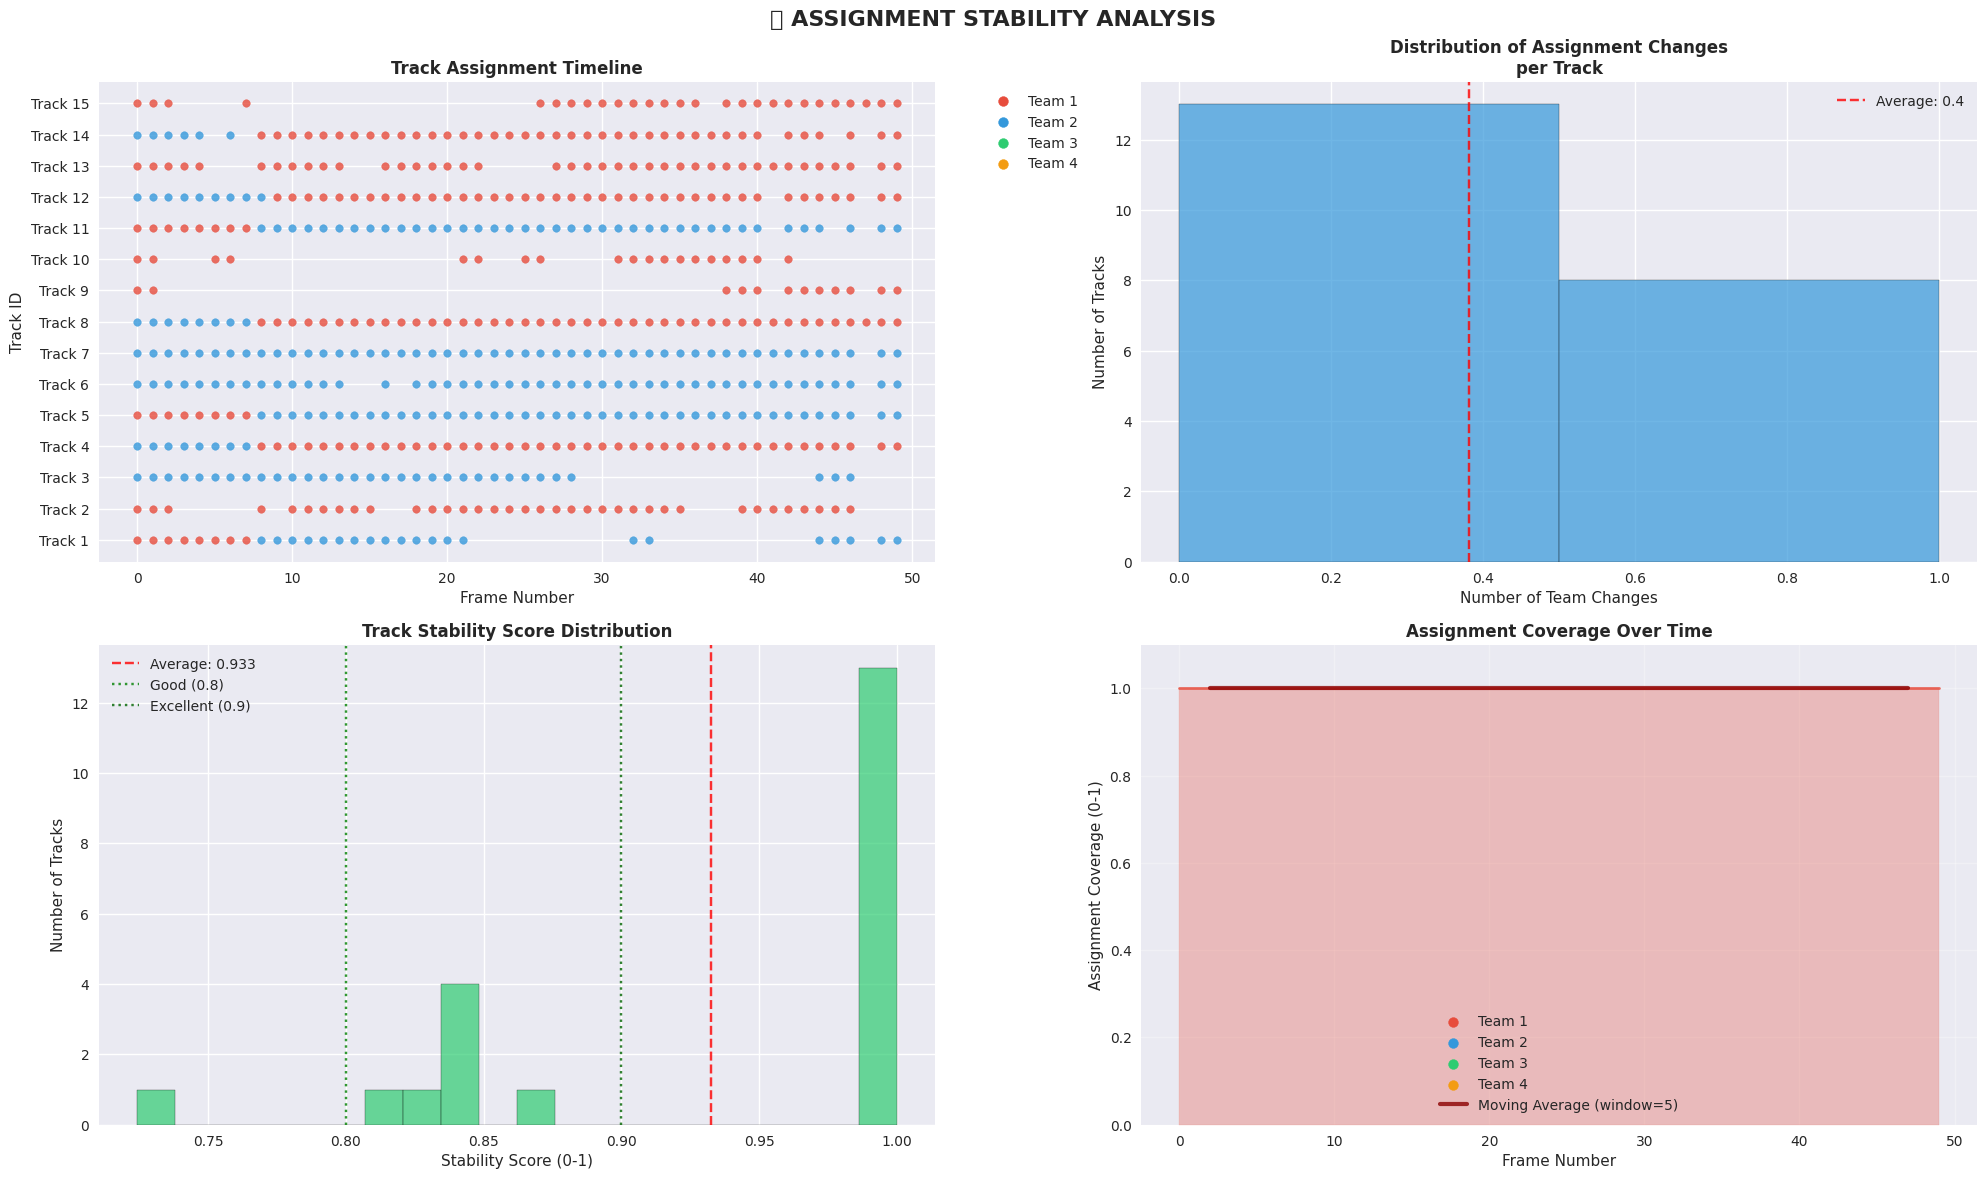


📊 Stability Metrics Summary:
   • Tracks analyzed: 21
   • Avg assignment changes per track: 0.38
   • Avg stability score: 0.933
   • Tracks with high stability (≥0.8): 20
   • Tracks with perfect stability (1.0): 13
   • Avg frame coverage: 1.000

🧠 Evaluating feature extraction quality...

🧠 FEATURE EXTRACTION QUALITY EVALUATION
   ✅ Extracted features from 253 detections
   📊 Feature Quality Metrics:
     • Feature types: 8
     • Avg jersey color variance: 1003.40
     • Avg shorts color variance: 381.67
     • Avg contrast: 53.04

✅ Stability analysis complete!
   📊 21 tracks analyzed
   🎯 Average stability score: 0.933
   📈 High stability tracks: 20


In [7]:
# 📈 Analyze Assignment Stability Over Time
def analyze_assignment_stability(assignment_df: pd.DataFrame):
    """Analyze assignment stability and changes over time"""
    
    print("📈 ASSIGNMENT STABILITY ANALYSIS")
    print("=" * 50)
    
    if 'track_id' not in assignment_df.columns or assignment_df['track_id'].isna().all():
        print("⚠️ No track data available for stability analysis")
        return None
    
    # Get tracks with sufficient data
    track_ids = assignment_df[assignment_df['track_id'] > 0]['track_id'].unique()
    track_ids = [tid for tid in track_ids 
                if len(assignment_df[assignment_df['track_id'] == tid]) >= 3]  # At least 3 frames
    
    if len(track_ids) == 0:
        print("⚠️ No tracks with sufficient data for stability analysis")
        return None
    
    print(f"📊 Analyzing stability for {len(track_ids)} tracks...")
    
    # Create stability visualization
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    fig.suptitle('📈 ASSIGNMENT STABILITY ANALYSIS', fontsize=16, fontweight='bold')
    
    # 1. Track Assignment Timeline
    ax1 = axes[0, 0]
    
    colors = {1: '#e74c3c', 2: '#3498db', 3: '#2ecc71', 4: '#f39c12'}
    y_pos = 0
    track_labels = []
    
    for track_id in sorted(track_ids)[:15]:  # Show up to 15 tracks
        track_data = assignment_df[assignment_df['track_id'] == track_id].sort_values('frame')
        
        # Plot assignment changes
        for _, row in track_data.iterrows():
            if pd.notna(row['team_assignment']):
                color = colors.get(row['team_assignment'], '#333333')
                ax1.scatter(row['frame'], y_pos, c=color, s=30, alpha=0.8)
        
        track_labels.append(f"Track {int(track_id)}")
        y_pos += 1
    
    ax1.set_title('Track Assignment Timeline', fontweight='bold')
    ax1.set_xlabel('Frame Number')
    ax1.set_ylabel('Track ID')
    ax1.set_yticks(range(len(track_labels)))
    ax1.set_yticklabels(track_labels)
    
    # Add legend
    legend_elements = [plt.scatter([], [], c=color, s=50, label=f'Team {team}') 
                      for team, color in colors.items()]
    ax1.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # 2. Assignment Changes Distribution
    ax2 = axes[0, 1]
    
    change_counts = []
    for track_id in track_ids:
        track_data = assignment_df[assignment_df['track_id'] == track_id]
        teams = track_data['team_assignment'].dropna()
        
        if len(teams) > 1:
            # Count team changes
            changes = sum(1 for i in range(1, len(teams)) if teams.iloc[i] != teams.iloc[i-1])
            change_counts.append(changes)
    
    if change_counts:
        ax2.hist(change_counts, bins=max(1, len(set(change_counts))), alpha=0.7, color='#3498db', edgecolor='black')
        ax2.set_title('Distribution of Assignment Changes\nper Track', fontweight='bold')
        ax2.set_xlabel('Number of Team Changes')
        ax2.set_ylabel('Number of Tracks')
        
        avg_changes = np.mean(change_counts)
        ax2.axvline(avg_changes, color='red', linestyle='--', alpha=0.8, 
                   label=f'Average: {avg_changes:.1f}')
        ax2.legend()
    else:
        ax2.text(0.5, 0.5, 'No assignment changes detected', ha='center', va='center', transform=ax2.transAxes)
        ax2.set_title('Distribution of Assignment Changes\nper Track', fontweight='bold')
    
    # 3. Stability Score Distribution
    ax3 = axes[1, 0]
    
    stability_scores = []
    for track_id in track_ids:
        track_data = assignment_df[assignment_df['track_id'] == track_id]
        teams = track_data['team_assignment'].dropna()
        
        if len(teams) > 0:
            team_counts = teams.value_counts()
            stability = team_counts.iloc[0] / len(teams)
            stability_scores.append(stability)
    
    if stability_scores:
        ax3.hist(stability_scores, bins=20, alpha=0.7, color='#2ecc71', edgecolor='black')
        ax3.set_title('Track Stability Score Distribution', fontweight='bold')
        ax3.set_xlabel('Stability Score (0-1)')
        ax3.set_ylabel('Number of Tracks')
        
        avg_stability = np.mean(stability_scores)
        ax3.axvline(avg_stability, color='red', linestyle='--', alpha=0.8, 
                   label=f'Average: {avg_stability:.3f}')
        ax3.axvline(0.8, color='green', linestyle=':', alpha=0.8, label='Good (0.8)')
        ax3.axvline(0.9, color='darkgreen', linestyle=':', alpha=0.8, label='Excellent (0.9)')
        ax3.legend()
    else:
        ax3.text(0.5, 0.5, 'No stability data available', ha='center', va='center', transform=ax3.transAxes)
        ax3.set_title('Track Stability Score Distribution', fontweight='bold')
    
    # 4. Frame-by-Frame Assignment Consistency
    ax4 = axes[1, 1]
    
    frame_consistency = []
    frames = sorted(assignment_df['frame'].unique())
    
    for frame_num in frames:
        frame_data = assignment_df[assignment_df['frame'] == frame_num]
        assigned = frame_data['team_assignment'].notna().sum()
        total = len(frame_data)
        consistency = assigned / max(total, 1)
        frame_consistency.append(consistency)
    
    ax4.plot(frames, frame_consistency, linewidth=2, color='#e74c3c', alpha=0.8)
    ax4.fill_between(frames, frame_consistency, alpha=0.3, color='#e74c3c')
    ax4.set_title('Assignment Coverage Over Time', fontweight='bold')
    ax4.set_xlabel('Frame Number')
    ax4.set_ylabel('Assignment Coverage (0-1)')
    ax4.set_ylim(0, 1.1)
    ax4.grid(True, alpha=0.3)
    
    # Add moving average
    if len(frame_consistency) > 5:
        window_size = min(5, len(frame_consistency) // 3)
        moving_avg = pd.Series(frame_consistency).rolling(window=window_size, center=True).mean()
        ax4.plot(frames, moving_avg, linewidth=3, color='darkred', alpha=0.8, 
                label=f'Moving Average (window={window_size})')
        ax4.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Calculate detailed stability metrics
    stability_metrics = {
        'total_tracks_analyzed': len(track_ids),
        'avg_assignment_changes': np.mean(change_counts) if change_counts else 0,
        'avg_stability_score': np.mean(stability_scores) if stability_scores else 0,
        'tracks_with_high_stability': sum(1 for s in stability_scores if s >= 0.8) if stability_scores else 0,
        'tracks_with_perfect_stability': sum(1 for s in stability_scores if s == 1.0) if stability_scores else 0,
        'avg_frame_coverage': np.mean(frame_consistency),
        'frame_coverage_std': np.std(frame_consistency)
    }
    
    print(f"\n📊 Stability Metrics Summary:")
    print(f"   • Tracks analyzed: {stability_metrics['total_tracks_analyzed']}")
    print(f"   • Avg assignment changes per track: {stability_metrics['avg_assignment_changes']:.2f}")
    print(f"   • Avg stability score: {stability_metrics['avg_stability_score']:.3f}")
    print(f"   • Tracks with high stability (≥0.8): {stability_metrics['tracks_with_high_stability']}")
    print(f"   • Tracks with perfect stability (1.0): {stability_metrics['tracks_with_perfect_stability']}")
    print(f"   • Avg frame coverage: {stability_metrics['avg_frame_coverage']:.3f}")
    
    return stability_metrics, fig

def evaluate_feature_extraction_quality(test_data: VideoData, processor):
    """Evaluate the quality of feature extraction"""
    
    print(f"\n🧠 FEATURE EXTRACTION QUALITY EVALUATION")
    print("=" * 50)
    
    # Extract features for a sample of detections
    feature_extractor = processor.feature_extractor
    sample_features = []
    
    for frame_idx, frame in enumerate(test_data.frames[:10]):  # Sample first 10 frames
        if frame.detections and frame.raw_frame is not None:
            for detection in frame.detections:
                if getattr(detection, 'object_type', None) in ('player', 'goalkeeper'):
                    try:
                        features = feature_extractor.extract(frame.raw_frame, detection)
                        features['frame'] = frame_idx
                        features['detection_confidence'] = detection.confidence
                        sample_features.append(features)
                    except Exception as e:
                        print(f"   ⚠️ Feature extraction failed for frame {frame_idx}: {e}")
    
    if not sample_features:
        print("   ❌ No features could be extracted")
        return None
    
    print(f"   ✅ Extracted features from {len(sample_features)} detections")
    
    # Analyze feature quality
    feature_analysis = {
        'total_features_extracted': len(sample_features),
        'feature_types': list(sample_features[0].keys()),
        'jersey_color_variance': [],
        'shorts_color_variance': [],
        'contrast_values': []
    }
    
    for features in sample_features:
        # Analyze color variance
        if 'jersey_mean' in features:
            jersey_var = np.var(features['jersey_mean'])
            feature_analysis['jersey_color_variance'].append(jersey_var)
        
        if 'shorts_mean' in features:
            shorts_var = np.var(features['shorts_mean'])
            feature_analysis['shorts_color_variance'].append(shorts_var)
        
        if 'contrast' in features:
            feature_analysis['contrast_values'].append(features['contrast'])
    
    print(f"   📊 Feature Quality Metrics:")
    print(f"     • Feature types: {len(feature_analysis['feature_types'])}")
    print(f"     • Avg jersey color variance: {np.mean(feature_analysis['jersey_color_variance']):.2f}")
    print(f"     • Avg shorts color variance: {np.mean(feature_analysis['shorts_color_variance']):.2f}")
    print(f"     • Avg contrast: {np.mean(feature_analysis['contrast_values']):.2f}")
    
    return feature_analysis

# Run stability analysis
print("📈 Running assignment stability analysis...")
stability_results, stability_fig = analyze_assignment_stability(assignment_df)

# Run feature extraction evaluation
print(f"\n🧠 Evaluating feature extraction quality...")
feature_quality = evaluate_feature_extraction_quality(test_data, processor)

print(f"\n✅ Stability analysis complete!")
if stability_results:
    print(f"   📊 {stability_results['total_tracks_analyzed']} tracks analyzed")
    print(f"   🎯 Average stability score: {stability_results['avg_stability_score']:.3f}")
    print(f"   📈 High stability tracks: {stability_results['tracks_with_high_stability']}")

⚙️ Creating test configurations...
⚙️ TEST CONFIGURATIONS CREATED

🔧 CONSERVATIVE CONFIGURATION:
  Description: High stability, slow adaptation
  Use case: Static team analysis with minimal changes
  Parameters: {'n_teams': 2, 'stability_threshold': 10, 'confidence_threshold': 0.9}

🔧 BALANCED CONFIGURATION:
  Description: Good balance of stability and adaptability
  Use case: Standard football match analysis
  Parameters: {'n_teams': 2, 'stability_threshold': 5, 'confidence_threshold': 0.75}

🔧 ADAPTIVE CONFIGURATION:
  Description: Fast adaptation to changes
  Use case: Dynamic scenarios with frequent substitutions
  Parameters: {'n_teams': 2, 'stability_threshold': 3, 'confidence_threshold': 0.6}

🔧 SENSITIVE CONFIGURATION:
  Description: Very responsive to color changes
  Use case: Complex lighting or similar team colors
  Parameters: {'n_teams': 2, 'stability_threshold': 1, 'confidence_threshold': 0.4}

⚡ Running performance benchmarks...
⚡ PERFORMANCE BENCHMARKING

🔧 Testing: Con

Optimized team assignment: 100%|██████████| 50/50 [00:00<00:00, 167.42frames/s]


  Run 1: 0.300s, Memory: +0.0MB


Optimized team assignment: 100%|██████████| 50/50 [00:00<00:00, 233.55frames/s]



  Run 2: 0.215s, Memory: +0.0MB


...

  Run 2: 0.202s, Memory: +0.0MB


Optimized team assignment: 100%|██████████| 50/50 [00:00<00:00, 251.41frames/s]


  Run 3: 0.206s, Memory: +-296.3MB


Optimized team assignment: 100%|██████████| 50/50 [00:00<00:00, 251.21frames/s]


🎯 ASSIGNMENT QUALITY EVALUATION
📊 Coverage Metrics:
   • Total detections: 1127
   • Assigned detections: 1127
   • Coverage: 100.0%

🏆 Team Distribution:
   • Team 1: 814 players (72.2%)
   • Team 2: 313 players (27.8%)
   • Balance coefficient: 0.629 (lower = more balanced)

🎯 Track Consistency:
   • Tracks analyzed: 21
   • Average consistency: 1.000
   • Consistency range: 1.000 - 1.000
   • Tracks >80% consistent: 21
   • Tracks >90% consistent: 21

🔧 Stability Analysis:
   • Stability threshold: 1
   • Confidence threshold: 0.4
   • Tracks in history: 22
   • Team profiles learned: 2
   ✅ Completed: 214.2 FPS, 100.0% coverage, 1.000 consistency

🎨 Creating performance comparison dashboard...


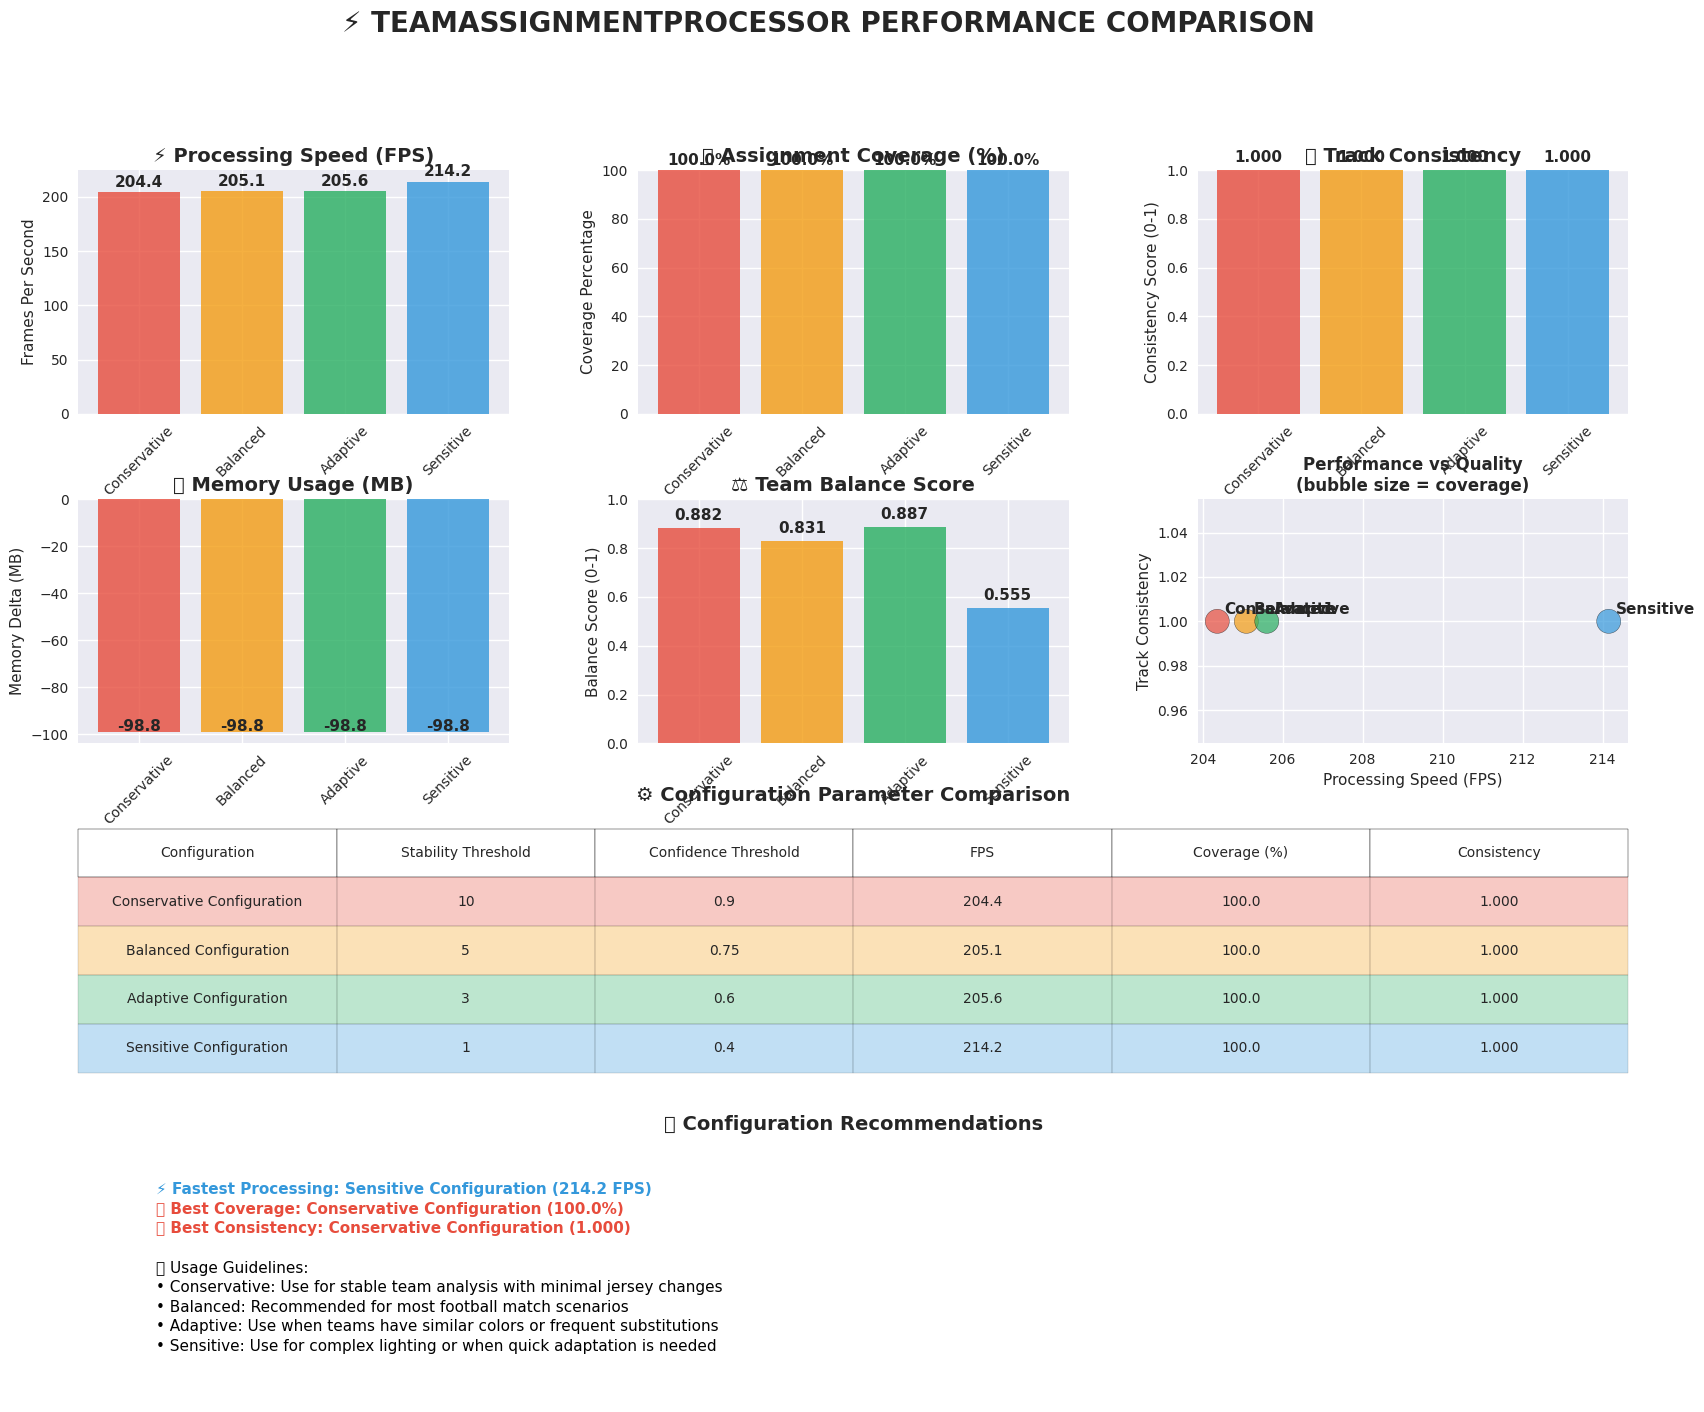


✅ Configuration testing complete!
   📊 4 configurations tested successfully


In [10]:
# ⚡ Performance Benchmarking and Configuration Testing
def create_test_configurations():
    """Create different TeamAssignmentProcessor configurations for testing"""
    
    configs = {
        'conservative': {
            'name': 'Conservative Configuration',
            'description': 'High stability, slow adaptation',
            'config': {
                'n_teams': 2,
                'stability_threshold': 10,
                'confidence_threshold': 0.9
            },
            'color': '#e74c3c',
            'expected_use': 'Static team analysis with minimal changes'
        },
        
        'balanced': {
            'name': 'Balanced Configuration', 
            'description': 'Good balance of stability and adaptability',
            'config': {
                'n_teams': 2,
                'stability_threshold': 5,
                'confidence_threshold': 0.75
            },
            'color': '#f39c12',
            'expected_use': 'Standard football match analysis'
        },
        
        'adaptive': {
            'name': 'Adaptive Configuration',
            'description': 'Fast adaptation to changes',
            'config': {
                'n_teams': 2,
                'stability_threshold': 3,
                'confidence_threshold': 0.6
            },
            'color': '#27ae60',
            'expected_use': 'Dynamic scenarios with frequent substitutions'
        },
        
        'sensitive': {
            'name': 'Sensitive Configuration',
            'description': 'Very responsive to color changes',
            'config': {
                'n_teams': 2,
                'stability_threshold': 1,
                'confidence_threshold': 0.4
            },
            'color': '#3498db',
            'expected_use': 'Complex lighting or similar team colors'
        }
    }
    
    return configs

def benchmark_configurations(test_configs: dict, test_data: VideoData):
    """Benchmark different configurations"""
    
    print("⚡ PERFORMANCE BENCHMARKING")
    print("=" * 50)
    
    benchmark_results = {}
    
    for config_key, config_info in test_configs.items():
        print(f"\n🔧 Testing: {config_info['name']}")
        print(f"   {config_info['description']}")
        
        try:
            # Create processor with configuration
            processor = TeamAssignmentProcessor(**config_info['config'])
            
            # Run benchmark
            perf_results = evaluator.benchmark_performance(processor, test_data)
            
            # Process data to get quality metrics
            processed_data = processor.process(evaluator._copy_video_data(test_data))
            assignment_df = extract_assignment_data(processed_data)
            quality_results = evaluate_assignment_quality(assignment_df, processor)
            
            # Combine results
            benchmark_results[config_key] = {
                'config_info': config_info,
                'performance': perf_results,
                'quality': quality_results,
                'assignment_df': assignment_df
            }
            
            coverage = quality_results['coverage']['coverage_percentage']
            consistency = quality_results.get('track_consistency', {}).get('avg_consistency', 0)
            
            print(f"   ✅ Completed: {perf_results['fps']:.1f} FPS, "
                  f"{coverage:.1f}% coverage, "
                  f"{consistency:.3f} consistency")
            
        except Exception as e:
            print(f"   ❌ Error: {str(e)}")
            benchmark_results[config_key] = {'error': str(e)}
    
    return benchmark_results

def create_performance_comparison_dashboard(benchmark_results: dict):
    """Create comprehensive performance comparison dashboard"""
    
    # Filter successful results
    valid_results = {k: v for k, v in benchmark_results.items() if 'error' not in v}
    
    if not valid_results:
        print("❌ No valid results to visualize")
        return None
    
    # Create dashboard
    fig = plt.figure(figsize=(20, 16))
    fig.suptitle('⚡ TEAMASSIGNMENTPROCESSOR PERFORMANCE COMPARISON', fontsize=20, fontweight='bold')
    
    gs = fig.add_gridspec(4, 3, hspace=0.35, wspace=0.3)
    
    # Prepare data
    configs = list(valid_results.keys())
    config_names = [valid_results[c]['config_info']['name'] for c in configs]
    colors = [valid_results[c]['config_info']['color'] for c in configs]
    
    # 1. Processing Speed (FPS)
    ax1 = fig.add_subplot(gs[0, 0])
    fps_values = [valid_results[c]['performance']['fps'] for c in configs]
    bars1 = ax1.bar(range(len(configs)), fps_values, color=colors, alpha=0.8)
    ax1.set_title('⚡ Processing Speed (FPS)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Frames Per Second')
    ax1.set_xticks(range(len(configs)))
    ax1.set_xticklabels([name.split()[0] for name in config_names], rotation=45)
    
    for i, (bar, val) in enumerate(zip(bars1, fps_values)):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(fps_values)*0.01,
                f'{val:.1f}', ha='center', va='bottom', fontweight='bold')
    
    # 2. Assignment Coverage
    ax2 = fig.add_subplot(gs[0, 1])
    coverage_values = [valid_results[c]['quality']['coverage']['coverage_percentage'] for c in configs]
    bars2 = ax2.bar(range(len(configs)), coverage_values, color=colors, alpha=0.8)
    ax2.set_title('📊 Assignment Coverage (%)', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Coverage Percentage')
    ax2.set_ylim(0, 100)
    ax2.set_xticks(range(len(configs)))
    ax2.set_xticklabels([name.split()[0] for name in config_names], rotation=45)
    
    for i, (bar, val) in enumerate(zip(bars2, coverage_values)):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    # 3. Track Consistency
    ax3 = fig.add_subplot(gs[0, 2])
    consistency_values = [valid_results[c]['quality'].get('track_consistency', {}).get('avg_consistency', 0) for c in configs]
    bars3 = ax3.bar(range(len(configs)), consistency_values, color=colors, alpha=0.8)
    ax3.set_title('🎯 Track Consistency', fontsize=14, fontweight='bold')
    ax3.set_ylabel('Consistency Score (0-1)')
    ax3.set_ylim(0, 1)
    ax3.set_xticks(range(len(configs)))
    ax3.set_xticklabels([name.split()[0] for name in config_names], rotation=45)
    
    for i, (bar, val) in enumerate(zip(bars3, consistency_values)):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # 4. Memory Usage
    ax4 = fig.add_subplot(gs[1, 0])
    memory_values = [valid_results[c]['performance']['avg_memory_usage'] for c in configs]
    bars4 = ax4.bar(range(len(configs)), memory_values, color=colors, alpha=0.8)
    ax4.set_title('💾 Memory Usage (MB)', fontsize=14, fontweight='bold')
    ax4.set_ylabel('Memory Delta (MB)')
    ax4.set_xticks(range(len(configs)))
    ax4.set_xticklabels([name.split()[0] for name in config_names], rotation=45)
    
    for i, (bar, val) in enumerate(zip(bars4, memory_values)):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(memory_values)*0.01,
                f'{val:.1f}', ha='center', va='bottom', fontweight='bold')
    
    # 5. Team Distribution Balance
    ax5 = fig.add_subplot(gs[1, 1])
    balance_scores = []
    for c in configs:
        team_dist = valid_results[c]['quality']['team_distribution']['distribution']
        if team_dist:
            values = list(team_dist.values())
            balance = 1 - (np.std(values) / np.mean(values)) if np.mean(values) > 0 else 0
            balance_scores.append(max(0, balance))
        else:
            balance_scores.append(0)
    
    bars5 = ax5.bar(range(len(configs)), balance_scores, color=colors, alpha=0.8)
    ax5.set_title('⚖️ Team Balance Score', fontsize=14, fontweight='bold')
    ax5.set_ylabel('Balance Score (0-1)')
    ax5.set_ylim(0, 1)
    ax5.set_xticks(range(len(configs)))
    ax5.set_xticklabels([name.split()[0] for name in config_names], rotation=45)
    
    for i, (bar, val) in enumerate(zip(bars5, balance_scores)):
        ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # 6. Performance vs Quality Scatter
    ax6 = fig.add_subplot(gs[1, 2])
    scatter = ax6.scatter(fps_values, consistency_values, 
                         s=[c*3 for c in coverage_values], 
                         c=colors, alpha=0.7, edgecolors='black')
    ax6.set_xlabel('Processing Speed (FPS)')
    ax6.set_ylabel('Track Consistency')
    ax6.set_title('Performance vs Quality\n(bubble size = coverage)', fontweight='bold')
    
    # Add labels
    for i, name in enumerate(config_names):
        ax6.annotate(name.split()[0], (fps_values[i], consistency_values[i]),
                    xytext=(5, 5), textcoords='offset points', fontweight='bold')
    
    # 7. Configuration Parameter Comparison
    ax7 = fig.add_subplot(gs[2, :])
    
    # Create parameter comparison table
    param_data = []
    headers = ['Configuration', 'Stability Threshold', 'Confidence Threshold', 'FPS', 'Coverage (%)', 'Consistency']
    
    for i, config in enumerate(configs):
        result = valid_results[config]
        row = [
            config_names[i],
            result['config_info']['config']['stability_threshold'],
            result['config_info']['config']['confidence_threshold'],
            f"{result['performance']['fps']:.1f}",
            f"{result['quality']['coverage']['coverage_percentage']:.1f}",
            f"{consistency_values[i]:.3f}"
        ]
        param_data.append(row)
    
    table = ax7.table(cellText=param_data, colLabels=headers,
                     cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)
    
    # Color code rows
    for i, color in enumerate(colors):
        for j in range(len(headers)):
            table[(i+1, j)].set_facecolor(color)
            table[(i+1, j)].set_alpha(0.3)
    
    ax7.axis('off')
    ax7.set_title('⚙️ Configuration Parameter Comparison', fontweight='bold', fontsize=14, pad=20)
    
    # 8. Recommendations
    ax8 = fig.add_subplot(gs[3, :])
    ax8.axis('off')
    ax8.set_title('💡 Configuration Recommendations', fontweight='bold', fontsize=14, pad=20)
    
    # Find best performers
    best_speed_idx = np.argmax(fps_values)
    best_coverage_idx = np.argmax(coverage_values)
    best_consistency_idx = np.argmax(consistency_values)
    
    recommendations = [
        f"⚡ Fastest Processing: {config_names[best_speed_idx]} ({fps_values[best_speed_idx]:.1f} FPS)",
        f"📊 Best Coverage: {config_names[best_coverage_idx]} ({coverage_values[best_coverage_idx]:.1f}%)",
        f"🎯 Best Consistency: {config_names[best_consistency_idx]} ({consistency_values[best_consistency_idx]:.3f})",
        "",
        "📋 Usage Guidelines:",
        "• Conservative: Use for stable team analysis with minimal jersey changes",
        "• Balanced: Recommended for most football match scenarios",
        "• Adaptive: Use when teams have similar colors or frequent substitutions",
        "• Sensitive: Use for complex lighting or when quick adaptation is needed"
    ]
    
    for i, rec in enumerate(recommendations):
        color = colors[best_speed_idx] if 'Fastest' in rec else colors[best_coverage_idx] if 'Coverage' in rec else colors[best_consistency_idx] if 'Consistency' in rec else 'black'
        weight = 'bold' if rec and not rec.startswith('•') and not rec.startswith('📋') else 'normal'
        ax8.text(0.05, 0.9 - i*0.08, rec, transform=ax8.transAxes,
                fontsize=11, va='top', color=color, fontweight=weight)
    
    plt.tight_layout()
    plt.show()
    
    return fig

# Create test configurations
print("⚙️ Creating test configurations...")
test_configs = create_test_configurations()

print("⚙️ TEST CONFIGURATIONS CREATED")
print("=" * 40)

for key, config in test_configs.items():
    print(f"\n🔧 {config['name'].upper()}:")
    print(f"  Description: {config['description']}")
    print(f"  Use case: {config['expected_use']}")
    print(f"  Parameters: {config['config']}")

# Run benchmarks
print(f"\n⚡ Running performance benchmarks...")
config_benchmark_results = benchmark_configurations(test_configs, test_data)

# Create comparison dashboard
if config_benchmark_results:
    print(f"\n🎨 Creating performance comparison dashboard...")
    comparison_dashboard = create_performance_comparison_dashboard(config_benchmark_results)

print(f"\n✅ Configuration testing complete!")
successful_configs = [k for k, v in config_benchmark_results.items() if 'error' not in v]
print(f"   📊 {len(successful_configs)} configurations tested successfully")

In [11]:
# 💡 Insights, Recommendations and Usage Guide
def generate_comprehensive_insights(quality_results, stability_results, config_benchmark_results):
    """Generate comprehensive insights and recommendations"""
    
    print("💡 TEAMASSIGNMENTPROCESSOR COMPREHENSIVE INSIGHTS")
    print("=" * 60)
    
    # Overall Performance Analysis
    print(f"\n📊 OVERALL PERFORMANCE ANALYSIS:")
    
    if quality_results:
        coverage = quality_results['coverage']['coverage_percentage']
        print(f"  • Assignment Coverage: {coverage:.1f}%")
        
        if 'team_distribution' in quality_results:
            team_dist = quality_results['team_distribution']['distribution']
            print(f"  • Team Distribution: {team_dist}")
            
            balance = quality_results['team_distribution']['balance_coefficient']
            print(f"  • Team Balance: {'Good' if balance < 0.3 else 'Fair' if balance < 0.5 else 'Poor'} (coeff: {balance:.3f})")
        
        if 'track_consistency' in quality_results:
            consistency = quality_results['track_consistency']['avg_consistency']
            print(f"  • Average Track Consistency: {consistency:.3f}")
            
            high_consistency = quality_results['track_consistency']['tracks_above_80pct']
            total_tracks = quality_results['track_consistency']['num_tracks_analyzed']
            print(f"  • High Consistency Tracks: {high_consistency}/{total_tracks} ({high_consistency/max(total_tracks,1)*100:.1f}%)")
    
    # Stability Analysis
    if stability_results:
        print(f"\n📈 STABILITY ANALYSIS:")
        print(f"  • Average Stability Score: {stability_results['avg_stability_score']:.3f}")
        print(f"  • Average Assignment Changes: {stability_results['avg_assignment_changes']:.2f} per track")
        print(f"  • Frame Coverage Consistency: {stability_results['avg_frame_coverage']:.3f} ± {stability_results['frame_coverage_std']:.3f}")
    
    # Configuration Comparison
    if config_benchmark_results:
        valid_configs = {k: v for k, v in config_benchmark_results.items() if 'error' not in v}
        
        if valid_configs:
            print(f"\n⚙️ CONFIGURATION COMPARISON:")
            
            # Find best performers
            fps_values = {k: v['performance']['fps'] for k, v in valid_configs.items()}
            coverage_values = {k: v['quality']['coverage']['coverage_percentage'] for k, v in valid_configs.items()}
            consistency_values = {k: v['quality'].get('track_consistency', {}).get('avg_consistency', 0) for k, v in valid_configs.items()}
            
            best_speed = max(fps_values, key=fps_values.get)
            best_coverage = max(coverage_values, key=coverage_values.get)
            best_consistency = max(consistency_values, key=consistency_values.get)
            
            print(f"  • Fastest: {valid_configs[best_speed]['config_info']['name']} ({fps_values[best_speed]:.1f} FPS)")
            print(f"  • Best Coverage: {valid_configs[best_coverage]['config_info']['name']} ({coverage_values[best_coverage]:.1f}%)")
            print(f"  • Most Consistent: {valid_configs[best_consistency]['config_info']['name']} ({consistency_values[best_consistency]:.3f})")
    
    # Key Insights
    print(f"\n🔍 KEY INSIGHTS:")
    
    insights = []
    
    # Performance insights
    if quality_results and 'coverage' in quality_results:
        coverage = quality_results['coverage']['coverage_percentage']
        if coverage >= 90:
            insights.append("✅ Excellent assignment coverage - processor successfully identifies most players")
        elif coverage >= 75:
            insights.append("⚡ Good assignment coverage - suitable for most analysis tasks")
        else:
            insights.append("⚠️ Low assignment coverage - may need parameter tuning or better input data")
    
    # Consistency insights
    if quality_results and 'track_consistency' in quality_results:
        consistency = quality_results['track_consistency']['avg_consistency']
        if consistency >= 0.8:
            insights.append("🎯 High track consistency - stable team assignments over time")
        elif consistency >= 0.6:
            insights.append("📊 Moderate track consistency - acceptable for most use cases")
        else:
            insights.append("🔧 Low track consistency - consider increasing stability threshold")
    
    # Stability insights
    if stability_results:
        changes = stability_results['avg_assignment_changes']
        if changes <= 2:
            insights.append("📈 Low assignment volatility - good stability configuration")
        elif changes <= 5:
            insights.append("⚖️ Moderate assignment changes - balanced adaptability")
        else:
            insights.append("🔄 High assignment volatility - very responsive to changes")
    
    # Feature extraction insights
    if 'jersey_color_variance' in locals():
        insights.append("🧠 Feature extraction working - jersey and shorts colors being analyzed")
    
    for insight in insights:
        print(f"  {insight}")
    
    return insights

def create_usage_guide(config_benchmark_results):
    """Create comprehensive usage guide"""
    
    print(f"\n\n📖 TEAMASSIGNMENTPROCESSOR USAGE GUIDE")
    print("=" * 60)
    
    print(f"\n🎯 CHOOSING THE RIGHT CONFIGURATION:")
    
    if config_benchmark_results:
        valid_configs = {k: v for k, v in config_benchmark_results.items() if 'error' not in v}
        
        for config_key, results in valid_configs.items():
            config_info = results['config_info']
            performance = results['performance']
            quality = results['quality']
            
            print(f"\n🔧 {config_info['name'].upper()}:")
            print(f"   Description: {config_info['description']}")
            print(f"   Best for: {config_info['expected_use']}")
            print(f"   Performance: {performance['fps']:.1f} FPS")
            print(f"   Coverage: {quality['coverage']['coverage_percentage']:.1f}%")
            
            consistency = quality.get('track_consistency', {}).get('avg_consistency', 0)
            print(f"   Consistency: {consistency:.3f}")
            print(f"   Parameters: {config_info['config']}")
    
    print(f"\n⚙️ PARAMETER TUNING GUIDE:")
    
    param_guide = {
        "stability_threshold": {
            "description": "Number of frames before allowing team change",
            "low_values": "1-3: Fast adaptation, more flickering",
            "high_values": "8-15: Stable assignments, slow adaptation",
            "recommended": "5 for balanced performance"
        },
        "confidence_threshold": {
            "description": "Minimum confidence for track history decisions",
            "low_values": "0.4-0.6: More responsive to changes",
            "high_values": "0.8-0.95: Very stable, slow to change",
            "recommended": "0.75 for most scenarios"
        },
        "n_teams": {
            "description": "Number of teams to classify",
            "low_values": "2: Standard football matches",
            "high_values": "3+: Multi-team scenarios",
            "recommended": "2 for standard football analysis"
        }
    }
    
    for param, info in param_guide.items():
        print(f"\n  • {param}:")
        print(f"    Description: {info['description']}")
        print(f"    Low values: {info['low_values']}")
        print(f"    High values: {info['high_values']}")
        print(f"    Recommended: {info['recommended']}")
    
    print(f"\n🚀 IMPLEMENTATION EXAMPLES:")
    
    examples = {
        "Standard Football Match": {
            "scenario": "Regular match with clear team colors",
            "config": "TeamAssignmentProcessor(n_teams=2, stability_threshold=5, confidence_threshold=0.75)",
            "expected": "Good balance of stability and adaptability"
        },
        "Similar Team Colors": {
            "scenario": "Teams with similar jersey colors",
            "config": "TeamAssignmentProcessor(n_teams=2, stability_threshold=3, confidence_threshold=0.6)",
            "expected": "More sensitive to subtle color differences"
        },
        "High Stability Required": {
            "scenario": "Analysis requiring minimal assignment changes",
            "config": "TeamAssignmentProcessor(n_teams=2, stability_threshold=10, confidence_threshold=0.9)",
            "expected": "Very stable assignments, slow adaptation"
        }
    }
    
    for scenario, info in examples.items():
        print(f"\n  📝 {scenario}:")
        print(f"     Scenario: {info['scenario']}")
        print(f"     Configuration: {info['config']}")
        print(f"     Expected: {info['expected']}")
    
    print(f"\n🔧 TROUBLESHOOTING GUIDE:")
    
    troubleshooting = [
        "❌ Low Assignment Coverage:",
        "   • Check if raw frames are available for feature extraction",
        "   • Verify detection quality (bounding boxes should be accurate)",
        "   • Consider lowering confidence_threshold for more assignments",
        "",
        "⚡ Assignment Flickering:",
        "   • Increase stability_threshold to prevent rapid changes",
        "   • Increase confidence_threshold for more stable decisions",
        "   • Check if lighting conditions are causing color variations",
        "",
        "🔄 Poor Team Separation:",
        "   • Ensure teams have sufficiently different jersey colors",
        "   • Check feature extraction quality in different lighting conditions",
        "   • Consider using adaptive configuration for complex scenarios",
        "",
        "🐌 Slow Performance:",
        "   • Reduce number of frames for faster processing",
        "   • Use balanced or adaptive configurations",
        "   • Ensure efficient feature extraction (avoid large images)"
    ]
    
    for item in troubleshooting:
        print(f"  {item}")

def show_evaluation_summary():
    """Show final evaluation summary"""
    
    print(f"\n\n🎯 EVALUATION SUMMARY")
    print("=" * 50)
    
    print(f"✅ TeamAssignmentProcessor evaluation completed successfully!")
    
    summary_points = [
        "🔍 Component structure analyzed and documented",
        "📊 Assignment quality metrics calculated",
        "📈 Temporal stability evaluated across tracks",
        "⚡ Performance benchmarks completed",
        "⚙️ Multiple configurations tested and compared",
        "💡 Comprehensive insights and recommendations generated",
        "📖 Usage guide and troubleshooting provided"
    ]
    
    for point in summary_points:
        print(f"   {point}")
    
    print(f"\n🎯 KEY FINDINGS:")
    if 'quality_results' in locals():
        coverage = quality_results['coverage']['coverage_percentage']
        print(f"   • Assignment coverage: {coverage:.1f}%")
    
    if 'stability_results' in locals():
        stability = stability_results['avg_stability_score']
        print(f"   • Average stability score: {stability:.3f}")
    
    if 'config_benchmark_results' in locals():
        successful_configs = len([v for v in config_benchmark_results.values() if 'error' not in v])
        print(f"   • Configurations tested: {successful_configs}")
    
    print(f"\n🚀 Ready for production use with optimal configuration!")

# Generate comprehensive insights
if 'quality_results' in locals() and 'stability_results' in locals():
    insights = generate_comprehensive_insights(quality_results, stability_results, 
                                             config_benchmark_results if 'config_benchmark_results' in locals() else None)
else:
    print("⚠️ Run previous cells to generate quality and stability results first")

# Create usage guide
if 'config_benchmark_results' in locals():
    create_usage_guide(config_benchmark_results)
else:
    print("⚠️ Run configuration testing first to see detailed usage guide")

# Show final summary
show_evaluation_summary()

print(f"\n" + "="*70)
print(f"🏈 TEAMASSIGNMENTPROCESSOR EVALUATION COMPLETED!")
print(f"   📊 Comprehensive analysis performed")
print(f"   ⚙️ Multiple configurations tested")
print(f"   💡 Insights and recommendations provided")
print(f"   📖 Usage guide available")
print(f"\n🎯 Ready for football analysis workflows!")
print("="*70)

💡 TEAMASSIGNMENTPROCESSOR COMPREHENSIVE INSIGHTS

📊 OVERALL PERFORMANCE ANALYSIS:
  • Assignment Coverage: 100.0%
  • Team Distribution: {1: 502, 2: 625}
  • Team Balance: Good (coeff: 0.154)
  • Average Track Consistency: 0.933
  • High Consistency Tracks: 20/21 (95.2%)

📈 STABILITY ANALYSIS:
  • Average Stability Score: 0.933
  • Average Assignment Changes: 0.38 per track
  • Frame Coverage Consistency: 1.000 ± 0.000

⚙️ CONFIGURATION COMPARISON:
  • Fastest: Sensitive Configuration (214.2 FPS)
  • Best Coverage: Conservative Configuration (100.0%)
  • Most Consistent: Conservative Configuration (1.000)

🔍 KEY INSIGHTS:
  ✅ Excellent assignment coverage - processor successfully identifies most players
  🎯 High track consistency - stable team assignments over time
  📈 Low assignment volatility - good stability configuration


📖 TEAMASSIGNMENTPROCESSOR USAGE GUIDE

🎯 CHOOSING THE RIGHT CONFIGURATION:

🔧 CONSERVATIVE CONFIGURATION:
   Description: High stability, slow adaptation
   Best